**LSA16 Detector Usability Table (movement + zero rate + failure)**

This section builds a detector mapping table for LD-LSA16 using the Excel mapping information (Detector Name, ID, Movement).
Then it evaluates each detector using September time-series measurements:

Zero rate (count): percentage of timeFrames where count == 0

Controller failure: detectors reported as faulty in the intersection snapshot (hardwareStatus.faultDetectors)

Detectors are labeled:

✅ USABLE: not faulty and not always-zero

❌ NOT USABLE (X): faulty or always-zero (with reason)

### Detector Plausibility and Usability Check

Before using the detector measurements for demand generation, calibration, validation, and traffic prediction, a detector plausibility and usability check was performed. The purpose of this step was to identify detectors that provide reliable traffic measurements and to exclude detectors with reported faults or implausible time-series behavior.

The check combined two sources of information. First, the controller status files were evaluated to identify detectors that were explicitly reported as faulty by the traffic signal controller. Second, the detector time-series data were analyzed to detect implausible measurement patterns, especially detectors that reported zero counts for almost all time frames.

For each detector, the number of available time frames and the zero-rate of count measurements were calculated. The zero-rate describes the share of time frames in which the detector count was equal to zero. A low zero-rate can be plausible, especially during low-demand periods. However, a zero-rate close to 100% may indicate a broken detector, missing data, or an incorrect detector mapping.

Detectors were marked as not usable if they were reported as faulty by the controller or if their count measurements were nearly always zero. In addition, the detector mapping was considered to determine whether a detector was relevant for demand generation or mainly useful for consistency checks.

This plausibility and usability check ensured that only reliable detector measurements were used as input for demand generation, calibration, validation, and the LSTM-based prediction model.

For LSA16, the controller status indicated a detector failure state with two faulty detectors. The reported faulty detectors were ID 8 (WD41) and ID 9 (WD42). Although these detectors contained time-series data, they were excluded from demand generation and model inputs because they were explicitly marked as faulty by the controller.

The remaining detectors showed sufficient data availability and acceptable zero-rate values. Therefore, they were considered usable for further processing, depending on their role in the detector mapping.

In [2]:
from pathlib import Path
import json
import re
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell")
LSA_FOLDER = BASE_DIR / "LD-LSA16"

OUT_DIR = BASE_DIR / "aktuell_detectors_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}\.json$")

# detector_id: {name, approach, group}
TARGET_DETECTORS = {
    5:  {"name": "VD23",  "approach": "West",  "group": "Entry"},
    4:  {"name": "WD22",  "approach": "West",  "group": "Entry"},
    3:  {"name": "WD21",  "approach": "West",  "group": "Entry"},
    15: {"name": "D46",   "approach": "West",  "group": "Exit"},

    33: {"name": "VD13",  "approach": "South", "group": "Entry"},
    2:  {"name": "VD12",  "approach": "South", "group": "Entry"},
    1:  {"name": "VD11",  "approach": "South", "group": "Entry"},

    10: {"name": "VD43",  "approach": "East",  "group": "Entry"},
    11: {"name": "VD4.4", "approach": "East",  "group": "Entry"},
    13: {"name": "D23",   "approach": "East",  "group": "Exit"},

    7:  {"name": "VD32",  "approach": "North", "group": "Entry"},
    6:  {"name": "VD31",  "approach": "North", "group": "Entry"},
}

# ============================================================
# HELPERS
# ============================================================
def safe_get_value(det: dict, field: str):
    try:
        return det.get("reading", {}).get(field, {}).get("value", None)
    except Exception:
        return None


def safe_get_samples(det: dict, field: str, sample_key: str):
    try:
        return det.get("reading", {}).get(field, {}).get("samples", {}).get(sample_key, None)
    except Exception:
        return None


def analyze_detector_files(folder: Path, target_detectors: dict):
    rows = []

    files = sorted([p for p in folder.iterdir() if p.is_file() and DATE_PATTERN.match(p.name)])

    if not files:
        print(f"[WARNING] No JSON files found in {folder}")
        return pd.DataFrame()

    for file_path in files:
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[ERROR] Could not read {file_path.name}: {e}")
            continue

        timeframes = data.get("timeFrames", [])
        if not isinstance(timeframes, list):
            continue

        day = file_path.stem

        daily_stats = {
            det_id: {
                "date": day,
                "detector_id": det_id,
                "detector_name": det_meta["name"],
                "approach": det_meta["approach"],
                "group": det_meta["group"],
                "timeframes_present": 0,

                "count_nonzero_intervals": 0,
                "occupancy_nonzero_intervals": 0,
                "speed_nonzero_intervals": 0,

                "count_all_zero": True,
                "occupancy_all_zero": True,
                "speed_all_zero": True,

                "count_sum": 0.0,
                "occupancy_sum": 0.0,
                "speed_sum": 0.0,

                "confidence_min": None,
                "confidence_mean_values": [],

                "count_invalid_samples_sum": 0,
                "occupancy_invalid_samples_sum": 0,
                "speed_invalid_samples_sum": 0,

                "count_expected_samples_sum": 0,
                "occupancy_expected_samples_sum": 0,
                "speed_expected_samples_sum": 0,

                "count_included_samples_sum": 0,
                "occupancy_included_samples_sum": 0,
                "speed_included_samples_sum": 0,
            }
            for det_id, det_meta in target_detectors.items()
        }

        for tf in timeframes:
            detectors = tf.get("detectors", [])
            if not isinstance(detectors, list):
                continue

            for det in detectors:
                det_id = det.get("id")
                if det_id not in target_detectors:
                    continue

                rec = daily_stats[det_id]
                rec["timeframes_present"] += 1

                count_val = safe_get_value(det, "count")
                occ_val = safe_get_value(det, "occupancy")
                speed_val = safe_get_value(det, "speed")

                if count_val is not None:
                    try:
                        count_val = float(count_val)
                        rec["count_sum"] += count_val
                        if count_val > 0:
                            rec["count_nonzero_intervals"] += 1
                            rec["count_all_zero"] = False
                    except Exception:
                        pass

                if occ_val is not None:
                    try:
                        occ_val = float(occ_val)
                        rec["occupancy_sum"] += occ_val
                        if occ_val > 0:
                            rec["occupancy_nonzero_intervals"] += 1
                            rec["occupancy_all_zero"] = False
                    except Exception:
                        pass

                if speed_val is not None:
                    try:
                        speed_val = float(speed_val)
                        rec["speed_sum"] += speed_val
                        if speed_val > 0:
                            rec["speed_nonzero_intervals"] += 1
                            rec["speed_all_zero"] = False
                    except Exception:
                        pass

                confidence = det.get("confidence", None)
                if confidence is not None:
                    try:
                        confidence = float(confidence)
                        rec["confidence_mean_values"].append(confidence)
                        if rec["confidence_min"] is None:
                            rec["confidence_min"] = confidence
                        else:
                            rec["confidence_min"] = min(rec["confidence_min"], confidence)
                    except Exception:
                        pass

                for field in ["count", "occupancy", "speed"]:
                    invalid_val = safe_get_samples(det, field, "invalid")
                    expected_val = safe_get_samples(det, field, "expected")
                    included_val = safe_get_samples(det, field, "included")

                    if invalid_val is not None:
                        rec[f"{field}_invalid_samples_sum"] += invalid_val
                    if expected_val is not None:
                        rec[f"{field}_expected_samples_sum"] += expected_val
                    if included_val is not None:
                        rec[f"{field}_included_samples_sum"] += included_val

        for det_id in target_detectors:
            rec = daily_stats[det_id]

            conf_vals = rec.pop("confidence_mean_values")
            rec["confidence_mean"] = sum(conf_vals) / len(conf_vals) if conf_vals else None

            rec["problem_count_always_zero"] = rec["count_all_zero"]
            rec["problem_occupancy_always_zero"] = rec["occupancy_all_zero"]
            rec["problem_speed_always_zero"] = rec["speed_all_zero"]

            if rec["timeframes_present"] == 0:
                rec["suggestion"] = "NOT_PRESENT"
            elif rec["count_all_zero"]:
                rec["suggestion"] = "DO_NOT_USE_COUNT"
            elif rec["occupancy_all_zero"] and rec["speed_all_zero"]:
                rec["suggestion"] = "USE_FOR_COUNT_ONLY"
            elif rec["occupancy_all_zero"]:
                rec["suggestion"] = "COUNT_OK_OCC_ZERO"
            elif rec["speed_all_zero"]:
                rec["suggestion"] = "COUNT_OK_SPEED_ZERO"
            else:
                rec["suggestion"] = "USE"

            rows.append(rec)

    return pd.DataFrame(rows)


# ============================================================
# RUN
# ============================================================
df = analyze_detector_files(LSA_FOLDER, TARGET_DETECTORS)

if df.empty:
    print("[WARNING] No results produced.")
else:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["approach", "group", "detector_id", "date"]).reset_index(drop=True)

    out_full = OUT_DIR / "LSA16_detector_health_daily.csv"
    df.to_csv(out_full, index=False, encoding="utf-8-sig")

    summary = (
        df.groupby(["approach", "group", "detector_id", "detector_name"], as_index=False)
          .agg(
              n_days=("date", "count"),
              days_present=("timeframes_present", lambda s: int((s > 0).sum())),
              total_timeframes=("timeframes_present", "sum"),

              count_nonzero_days=("problem_count_always_zero", lambda s: int((~s).sum())),
              occupancy_nonzero_days=("problem_occupancy_always_zero", lambda s: int((~s).sum())),
              speed_nonzero_days=("problem_speed_always_zero", lambda s: int((~s).sum())),

              count_all_zero_days=("problem_count_always_zero", "sum"),
              occupancy_all_zero_days=("problem_occupancy_always_zero", "sum"),
              speed_all_zero_days=("problem_speed_always_zero", "sum"),

              total_count=("count_sum", "sum"),
              total_occupancy=("occupancy_sum", "sum"),
              total_speed=("speed_sum", "sum"),

              min_confidence=("confidence_min", "min"),
              mean_confidence=("confidence_mean", "mean"),

              count_invalid_samples=("count_invalid_samples_sum", "sum"),
              occupancy_invalid_samples=("occupancy_invalid_samples_sum", "sum"),
              speed_invalid_samples=("speed_invalid_samples_sum", "sum"),
          )
    )

    def final_flag(row):
        if row["days_present"] == 0:
            return "NOT_PRESENT"
        if row["count_all_zero_days"] == row["days_present"]:
            return "DO_NOT_USE_COUNT"
        if row["occupancy_all_zero_days"] == row["days_present"] and row["speed_all_zero_days"] == row["days_present"]:
            return "USE_FOR_COUNT_ONLY"
        if row["occupancy_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_OCC_ZERO"
        if row["speed_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_SPEED_ZERO"
        return "USE"

    summary["final_suggestion"] = summary.apply(final_flag, axis=1)

    summary = summary.sort_values(["approach", "group", "detector_id"]).reset_index(drop=True)

    out_summary = OUT_DIR / "LSA16_detector_health_summary.csv"
    summary.to_csv(out_summary, index=False, encoding="utf-8-sig")

    print("\nSaved files:")
    print(out_full)
    print(out_summary)

    print("\nDetector summary:")
    print(summary.to_string(index=False))


Saved files:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA16_detector_health_daily.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA16_detector_health_summary.csv

Detector summary:
approach group  detector_id detector_name  n_days  days_present  total_timeframes  count_nonzero_days  occupancy_nonzero_days  speed_nonzero_days  count_all_zero_days  occupancy_all_zero_days  speed_all_zero_days  total_count  total_occupancy  total_speed  min_confidence  mean_confidence  count_invalid_samples  occupancy_invalid_samples  speed_invalid_samples final_suggestion
    East Entry           10          VD43      32            28              2602                  28                      28                   0                    4                        4                   32     107379.0          43117.0          0.0           100.0            100.0                      0                          0        

**LSA10 Detector Usability & Demand Selection**

This section evaluates detector usability for LD-LSA10.

The following checks are performed:

Controller failure check (from intersection definition JSON)

Zero rate analysis from September detector time-series

Demand eligibility based on the mapping table rules

Detectors are classified as:

✅ USABLE – detector produces valid measurements

❌ X (NOT USABLE) – faulty or invalid data

⚠️ Not used for demand – valid but excluded by mapping

In [3]:
from pathlib import Path
import json
import re
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell")
LSA_FOLDER = BASE_DIR / "LD-LSA10"

OUT_DIR = BASE_DIR / "aktuell_detectors_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}\.json$")

# detector_id: {name, approach, group}
TARGET_DETECTORS = {
    1:  {"name": "VD11", "approach": "West",        "group": "Entry"},

    31: {"name": "WD52", "approach": "South",       "group": "Entry"},
    30: {"name": "WD51", "approach": "South",       "group": "Entry"},

    3:  {"name": "VD41", "approach": "East",        "group": "Entry"},
    4:  {"name": "VD42", "approach": "East",        "group": "Entry"},

    29: {"name": "WD32", "approach": "North-West",  "group": "Entry"},
    28: {"name": "WD31", "approach": "North-West",  "group": "Entry"},

    2:  {"name": "VD25", "approach": "North-East",  "group": "Entry"},
    26: {"name": "WD23", "approach": "North-East",  "group": "Entry"},
    27: {"name": "WD24", "approach": "North-East",  "group": "Entry"},
    25: {"name": "WD22", "approach": "North-East",  "group": "Entry"},
    24: {"name": "WD21", "approach": "North-East",  "group": "Entry"},
}

# ============================================================
# HELPERS
# ============================================================
def safe_get_value(det: dict, field: str):
    try:
        return det.get("reading", {}).get(field, {}).get("value", None)
    except Exception:
        return None


def safe_get_samples(det: dict, field: str, sample_key: str):
    try:
        return det.get("reading", {}).get(field, {}).get("samples", {}).get(sample_key, None)
    except Exception:
        return None


def analyze_detector_files(folder: Path, target_detectors: dict):
    rows = []

    files = sorted([p for p in folder.iterdir() if p.is_file() and DATE_PATTERN.match(p.name)])

    if not files:
        print(f"[WARNING] No JSON files found in {folder}")
        return pd.DataFrame()

    for file_path in files:
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[ERROR] Could not read {file_path.name}: {e}")
            continue

        timeframes = data.get("timeFrames", [])
        if not isinstance(timeframes, list):
            continue

        day = file_path.stem

        daily_stats = {
            det_id: {
                "date": day,
                "detector_id": det_id,
                "detector_name": det_meta["name"],
                "approach": det_meta["approach"],
                "group": det_meta["group"],
                "timeframes_present": 0,

                "count_nonzero_intervals": 0,
                "occupancy_nonzero_intervals": 0,
                "speed_nonzero_intervals": 0,

                "count_all_zero": True,
                "occupancy_all_zero": True,
                "speed_all_zero": True,

                "count_sum": 0.0,
                "occupancy_sum": 0.0,
                "speed_sum": 0.0,

                "confidence_min": None,
                "confidence_mean_values": [],

                "count_invalid_samples_sum": 0,
                "occupancy_invalid_samples_sum": 0,
                "speed_invalid_samples_sum": 0,

                "count_expected_samples_sum": 0,
                "occupancy_expected_samples_sum": 0,
                "speed_expected_samples_sum": 0,

                "count_included_samples_sum": 0,
                "occupancy_included_samples_sum": 0,
                "speed_included_samples_sum": 0,
            }
            for det_id, det_meta in target_detectors.items()
        }

        for tf in timeframes:
            detectors = tf.get("detectors", [])
            if not isinstance(detectors, list):
                continue

            for det in detectors:
                det_id = det.get("id")
                if det_id not in target_detectors:
                    continue

                rec = daily_stats[det_id]
                rec["timeframes_present"] += 1

                count_val = safe_get_value(det, "count")
                occ_val = safe_get_value(det, "occupancy")
                speed_val = safe_get_value(det, "speed")

                if count_val is not None:
                    try:
                        count_val = float(count_val)
                        rec["count_sum"] += count_val
                        if count_val > 0:
                            rec["count_nonzero_intervals"] += 1
                            rec["count_all_zero"] = False
                    except Exception:
                        pass

                if occ_val is not None:
                    try:
                        occ_val = float(occ_val)
                        rec["occupancy_sum"] += occ_val
                        if occ_val > 0:
                            rec["occupancy_nonzero_intervals"] += 1
                            rec["occupancy_all_zero"] = False
                    except Exception:
                        pass

                if speed_val is not None:
                    try:
                        speed_val = float(speed_val)
                        rec["speed_sum"] += speed_val
                        if speed_val > 0:
                            rec["speed_nonzero_intervals"] += 1
                            rec["speed_all_zero"] = False
                    except Exception:
                        pass

                confidence = det.get("confidence", None)
                if confidence is not None:
                    try:
                        confidence = float(confidence)
                        rec["confidence_mean_values"].append(confidence)
                        if rec["confidence_min"] is None:
                            rec["confidence_min"] = confidence
                        else:
                            rec["confidence_min"] = min(rec["confidence_min"], confidence)
                    except Exception:
                        pass

                for field in ["count", "occupancy", "speed"]:
                    invalid_val = safe_get_samples(det, field, "invalid")
                    expected_val = safe_get_samples(det, field, "expected")
                    included_val = safe_get_samples(det, field, "included")

                    if invalid_val is not None:
                        rec[f"{field}_invalid_samples_sum"] += invalid_val
                    if expected_val is not None:
                        rec[f"{field}_expected_samples_sum"] += expected_val
                    if included_val is not None:
                        rec[f"{field}_included_samples_sum"] += included_val

        for det_id in target_detectors:
            rec = daily_stats[det_id]

            conf_vals = rec.pop("confidence_mean_values")
            rec["confidence_mean"] = sum(conf_vals) / len(conf_vals) if conf_vals else None

            rec["problem_count_always_zero"] = rec["count_all_zero"]
            rec["problem_occupancy_always_zero"] = rec["occupancy_all_zero"]
            rec["problem_speed_always_zero"] = rec["speed_all_zero"]

            if rec["timeframes_present"] == 0:
                rec["suggestion"] = "NOT_PRESENT"
            elif rec["count_all_zero"]:
                rec["suggestion"] = "DO_NOT_USE_COUNT"
            elif rec["occupancy_all_zero"] and rec["speed_all_zero"]:
                rec["suggestion"] = "USE_FOR_COUNT_ONLY"
            elif rec["occupancy_all_zero"]:
                rec["suggestion"] = "COUNT_OK_OCC_ZERO"
            elif rec["speed_all_zero"]:
                rec["suggestion"] = "COUNT_OK_SPEED_ZERO"
            else:
                rec["suggestion"] = "USE"

            rows.append(rec)

    return pd.DataFrame(rows)


# ============================================================
# RUN
# ============================================================
df = analyze_detector_files(LSA_FOLDER, TARGET_DETECTORS)

if df.empty:
    print("[WARNING] No results produced.")
else:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["approach", "group", "detector_id", "date"]).reset_index(drop=True)

    out_full = OUT_DIR / "LSA10_detector_health_daily.csv"
    df.to_csv(out_full, index=False, encoding="utf-8-sig")

    summary = (
        df.groupby(["approach", "group", "detector_id", "detector_name"], as_index=False)
          .agg(
              n_days=("date", "count"),
              days_present=("timeframes_present", lambda s: int((s > 0).sum())),
              total_timeframes=("timeframes_present", "sum"),

              count_nonzero_days=("problem_count_always_zero", lambda s: int((~s).sum())),
              occupancy_nonzero_days=("problem_occupancy_always_zero", lambda s: int((~s).sum())),
              speed_nonzero_days=("problem_speed_always_zero", lambda s: int((~s).sum())),

              count_all_zero_days=("problem_count_always_zero", "sum"),
              occupancy_all_zero_days=("problem_occupancy_always_zero", "sum"),
              speed_all_zero_days=("problem_speed_always_zero", "sum"),

              total_count=("count_sum", "sum"),
              total_occupancy=("occupancy_sum", "sum"),
              total_speed=("speed_sum", "sum"),

              min_confidence=("confidence_min", "min"),
              mean_confidence=("confidence_mean", "mean"),

              count_invalid_samples=("count_invalid_samples_sum", "sum"),
              occupancy_invalid_samples=("occupancy_invalid_samples_sum", "sum"),
              speed_invalid_samples=("speed_invalid_samples_sum", "sum"),
          )
    )

    def final_flag(row):
        if row["days_present"] == 0:
            return "NOT_PRESENT"
        if row["count_all_zero_days"] == row["days_present"]:
            return "DO_NOT_USE_COUNT"
        if row["occupancy_all_zero_days"] == row["days_present"] and row["speed_all_zero_days"] == row["days_present"]:
            return "USE_FOR_COUNT_ONLY"
        if row["occupancy_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_OCC_ZERO"
        if row["speed_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_SPEED_ZERO"
        return "USE"

    summary["final_suggestion"] = summary.apply(final_flag, axis=1)

    summary = summary.sort_values(["approach", "group", "detector_id"]).reset_index(drop=True)

    out_summary = OUT_DIR / "LSA10_detector_health_summary.csv"
    summary.to_csv(out_summary, index=False, encoding="utf-8-sig")

    print("\nSaved files:")
    print(out_full)
    print(out_summary)

    print("\nDetector summary:")
    print(summary.to_string(index=False))


Saved files:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA10_detector_health_daily.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA10_detector_health_summary.csv

Detector summary:
  approach group  detector_id detector_name  n_days  days_present  total_timeframes  count_nonzero_days  occupancy_nonzero_days  speed_nonzero_days  count_all_zero_days  occupancy_all_zero_days  speed_all_zero_days  total_count  total_occupancy  total_speed  min_confidence  mean_confidence  count_invalid_samples  occupancy_invalid_samples  speed_invalid_samples    final_suggestion
      East Entry            3          VD41      32            32              3038                  32                      32                   0                    0                        0                   32     125874.0          64361.0          0.0           100.0            100.0                      0                          0 

**LSA9 Detector Usability & Demand Selection**

This section evaluates the detectors for LD-LSA8 using:

intersection controller status (fault detectors)

September detector measurements

mapping table constraints

Detectors are classified as:

Status	Meaning
✅ USABLE	detector produces valid measurements

❌ X (NOT USABLE)	faulty or always zero

⚠️ Not used for demand	valid but excluded by mapping rule

In [7]:
from pathlib import Path
import json
import re
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell")
LSA_FOLDER = BASE_DIR / "LD-LSA9"

OUT_DIR = BASE_DIR / "aktuell_detectors_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}\.json$")

# detector_id: {name, approach, group}
TARGET_DETECTORS = {
    2:  {"name": "VD12", "approach": "West",        "group": "Entry"},
    1:  {"name": "VD11", "approach": "West",        "group": "Entry"},

    10: {"name": "WD41", "approach": "South",       "group": "Entry"},

    8:  {"name": "VD31", "approach": "East",        "group": "Entry"},
    9:  {"name": "VD32", "approach": "East",        "group": "Entry"},

    6:  {"name": "VD24", "approach": "North-West",  "group": "Entry"},
    7:  {"name": "VD25", "approach": "North-West",  "group": "Entry"},
    4:  {"name": "WD22", "approach": "North-West",  "group": "Entry"},
    5:  {"name": "WD23", "approach": "North-West",  "group": "Entry"},

    3:  {"name": "WD21", "approach": "North-East",  "group": "Suspicious"},

    11: {"name": "VD51", "approach": "Middle",      "group": "Internal"},
}

# ============================================================
# HELPERS
# ============================================================
def safe_get_value(det: dict, field: str):
    try:
        return det.get("reading", {}).get(field, {}).get("value", None)
    except Exception:
        return None


def safe_get_samples(det: dict, field: str, sample_key: str):
    try:
        return det.get("reading", {}).get(field, {}).get("samples", {}).get(sample_key, None)
    except Exception:
        return None


def analyze_detector_files(folder: Path, target_detectors: dict):
    rows = []

    files = sorted([p for p in folder.iterdir() if p.is_file() and DATE_PATTERN.match(p.name)])

    if not files:
        print(f"[WARNING] No JSON files found in {folder}")
        return pd.DataFrame()

    for file_path in files:
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[ERROR] Could not read {file_path.name}: {e}")
            continue

        timeframes = data.get("timeFrames", [])
        if not isinstance(timeframes, list):
            continue

        day = file_path.stem

        daily_stats = {
            det_id: {
                "date": day,
                "detector_id": det_id,
                "detector_name": det_meta["name"],
                "approach": det_meta["approach"],
                "group": det_meta["group"],
                "timeframes_present": 0,

                "count_nonzero_intervals": 0,
                "occupancy_nonzero_intervals": 0,
                "speed_nonzero_intervals": 0,

                "count_all_zero": True,
                "occupancy_all_zero": True,
                "speed_all_zero": True,

                "count_sum": 0.0,
                "occupancy_sum": 0.0,
                "speed_sum": 0.0,

                "confidence_min": None,
                "confidence_mean_values": [],

                "count_invalid_samples_sum": 0,
                "occupancy_invalid_samples_sum": 0,
                "speed_invalid_samples_sum": 0,

                "count_expected_samples_sum": 0,
                "occupancy_expected_samples_sum": 0,
                "speed_expected_samples_sum": 0,

                "count_included_samples_sum": 0,
                "occupancy_included_samples_sum": 0,
                "speed_included_samples_sum": 0,
            }
            for det_id, det_meta in target_detectors.items()
        }

        for tf in timeframes:
            detectors = tf.get("detectors", [])
            if not isinstance(detectors, list):
                continue

            for det in detectors:
                det_id = det.get("id")
                if det_id not in target_detectors:
                    continue

                rec = daily_stats[det_id]
                rec["timeframes_present"] += 1

                count_val = safe_get_value(det, "count")
                occ_val = safe_get_value(det, "occupancy")
                speed_val = safe_get_value(det, "speed")

                if count_val is not None:
                    try:
                        count_val = float(count_val)
                        rec["count_sum"] += count_val
                        if count_val > 0:
                            rec["count_nonzero_intervals"] += 1
                            rec["count_all_zero"] = False
                    except Exception:
                        pass

                if occ_val is not None:
                    try:
                        occ_val = float(occ_val)
                        rec["occupancy_sum"] += occ_val
                        if occ_val > 0:
                            rec["occupancy_nonzero_intervals"] += 1
                            rec["occupancy_all_zero"] = False
                    except Exception:
                        pass

                if speed_val is not None:
                    try:
                        speed_val = float(speed_val)
                        rec["speed_sum"] += speed_val
                        if speed_val > 0:
                            rec["speed_nonzero_intervals"] += 1
                            rec["speed_all_zero"] = False
                    except Exception:
                        pass

                confidence = det.get("confidence", None)
                if confidence is not None:
                    try:
                        confidence = float(confidence)
                        rec["confidence_mean_values"].append(confidence)
                        if rec["confidence_min"] is None:
                            rec["confidence_min"] = confidence
                        else:
                            rec["confidence_min"] = min(rec["confidence_min"], confidence)
                    except Exception:
                        pass

                for field in ["count", "occupancy", "speed"]:
                    invalid_val = safe_get_samples(det, field, "invalid")
                    expected_val = safe_get_samples(det, field, "expected")
                    included_val = safe_get_samples(det, field, "included")

                    if invalid_val is not None:
                        rec[f"{field}_invalid_samples_sum"] += invalid_val
                    if expected_val is not None:
                        rec[f"{field}_expected_samples_sum"] += expected_val
                    if included_val is not None:
                        rec[f"{field}_included_samples_sum"] += included_val

        for det_id in target_detectors:
            rec = daily_stats[det_id]

            conf_vals = rec.pop("confidence_mean_values")
            rec["confidence_mean"] = sum(conf_vals) / len(conf_vals) if conf_vals else None

            rec["problem_count_always_zero"] = rec["count_all_zero"]
            rec["problem_occupancy_always_zero"] = rec["occupancy_all_zero"]
            rec["problem_speed_always_zero"] = rec["speed_all_zero"]

            if rec["timeframes_present"] == 0:
                rec["suggestion"] = "NOT_PRESENT"
            elif rec["count_all_zero"]:
                rec["suggestion"] = "DO_NOT_USE_COUNT"
            elif rec["occupancy_all_zero"] and rec["speed_all_zero"]:
                rec["suggestion"] = "USE_FOR_COUNT_ONLY"
            elif rec["occupancy_all_zero"]:
                rec["suggestion"] = "COUNT_OK_OCC_ZERO"
            elif rec["speed_all_zero"]:
                rec["suggestion"] = "COUNT_OK_SPEED_ZERO"
            else:
                rec["suggestion"] = "USE"

            rows.append(rec)

    return pd.DataFrame(rows)


# ============================================================
# RUN
# ============================================================
df = analyze_detector_files(LSA_FOLDER, TARGET_DETECTORS)

if df.empty:
    print("[WARNING] No results produced.")
else:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["approach", "group", "detector_id", "date"]).reset_index(drop=True)

    out_full = OUT_DIR / "LSA9_detector_health_daily.csv"
    df.to_csv(out_full, index=False, encoding="utf-8-sig")

    summary = (
        df.groupby(["approach", "group", "detector_id", "detector_name"], as_index=False)
          .agg(
              n_days=("date", "count"),
              days_present=("timeframes_present", lambda s: int((s > 0).sum())),
              total_timeframes=("timeframes_present", "sum"),

              count_nonzero_days=("problem_count_always_zero", lambda s: int((~s).sum())),
              occupancy_nonzero_days=("problem_occupancy_always_zero", lambda s: int((~s).sum())),
              speed_nonzero_days=("problem_speed_always_zero", lambda s: int((~s).sum())),

              count_all_zero_days=("problem_count_always_zero", "sum"),
              occupancy_all_zero_days=("problem_occupancy_always_zero", "sum"),
              speed_all_zero_days=("problem_speed_always_zero", "sum"),

              total_count=("count_sum", "sum"),
              total_occupancy=("occupancy_sum", "sum"),
              total_speed=("speed_sum", "sum"),

              min_confidence=("confidence_min", "min"),
              mean_confidence=("confidence_mean", "mean"),

              count_invalid_samples=("count_invalid_samples_sum", "sum"),
              occupancy_invalid_samples=("occupancy_invalid_samples_sum", "sum"),
              speed_invalid_samples=("speed_invalid_samples_sum", "sum"),
          )
    )

    def final_flag(row):
        if row["days_present"] == 0:
            return "NOT_PRESENT"
        if row["count_all_zero_days"] == row["days_present"]:
            return "DO_NOT_USE_COUNT"
        if row["occupancy_all_zero_days"] == row["days_present"] and row["speed_all_zero_days"] == row["days_present"]:
            return "USE_FOR_COUNT_ONLY"
        if row["occupancy_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_OCC_ZERO"
        if row["speed_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_SPEED_ZERO"
        return "USE"

    summary["final_suggestion"] = summary.apply(final_flag, axis=1)

    summary = summary.sort_values(["approach", "group", "detector_id"]).reset_index(drop=True)

    out_summary = OUT_DIR / "LSA9_detector_health_summary.csv"
    summary.to_csv(out_summary, index=False, encoding="utf-8-sig")

    print("\nSaved files:")
    print(out_full)
    print(out_summary)

    print("\nDetector summary:")
    print(summary.to_string(index=False))


Saved files:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA9_detector_health_daily.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA9_detector_health_summary.csv

Detector summary:
  approach      group  detector_id detector_name  n_days  days_present  total_timeframes  count_nonzero_days  occupancy_nonzero_days  speed_nonzero_days  count_all_zero_days  occupancy_all_zero_days  speed_all_zero_days  total_count  total_occupancy  total_speed  min_confidence  mean_confidence  count_invalid_samples  occupancy_invalid_samples  speed_invalid_samples    final_suggestion
      East      Entry            8          VD31      32            32              3038                  32                      32                   0                    0                        0                   32     169311.0          99411.0          0.0           100.0            100.0                      0                    

**LSA1 Detector Usability (movement + zero rate + failure)**

This section evaluates detectors for LD-LSA1 using:

Controller-reported failures (hardwareStatus.faultDetectors)

September time-series readings (zero rate of count)

Outputs:

A table with mapping fields (Detector, ID, Movement, Demand, edge_relation)

Zero-rate statistics from September data

USABLE / NOT USABLE (X) decision with reason

Explanation of what zero-rate means, and how usable detectors are used for demand / calibration

In [6]:
from pathlib import Path
import json
import re
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell")
LSA_FOLDER = BASE_DIR / "LD-LSA1"

OUT_DIR = BASE_DIR / "aktuell_detectors_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}\.json$")

# detector_id: {name, approach, group}
TARGET_DETECTORS = {
    # West approach
    8:  {"name": "DET12", "approach": "West",  "group": "Entry"},
    10: {"name": "DET22", "approach": "West",  "group": "Entry"},
    7:  {"name": "DET11", "approach": "West",  "group": "Entry"},
    9:  {"name": "DET21", "approach": "West",  "group": "Entry"},

    # South approach
    12: {"name": "DET32", "approach": "South", "group": "Entry"},
    11: {"name": "DET31", "approach": "South", "group": "Entry"},

    # East approach
    14: {"name": "DET42", "approach": "East",  "group": "Entry"},
    24: {"name": "DET44", "approach": "East",  "group": "Entry"},
    26: {"name": "DET52", "approach": "East",  "group": "Entry"},
    27: {"name": "DET61", "approach": "East",  "group": "Entry"},
    13: {"name": "DET41", "approach": "East",  "group": "Entry"},
    23: {"name": "DET43", "approach": "East",  "group": "Entry"},
    25: {"name": "DET51", "approach": "East",  "group": "Entry"},

    # North approach
    29: {"name": "DET72", "approach": "North", "group": "Entry"},
    39: {"name": "DET74", "approach": "North", "group": "Entry"},
    40: {"name": "DET81", "approach": "North", "group": "Entry"},
    28: {"name": "DET71", "approach": "North", "group": "Entry"},
    30: {"name": "DET73", "approach": "North", "group": "Entry"},
}

# ============================================================
# HELPERS
# ============================================================
def safe_get_value(det: dict, field: str):
    try:
        return det.get("reading", {}).get(field, {}).get("value", None)
    except Exception:
        return None


def safe_get_samples(det: dict, field: str, sample_key: str):
    try:
        return det.get("reading", {}).get(field, {}).get("samples", {}).get(sample_key, None)
    except Exception:
        return None


def analyze_detector_files(folder: Path, target_detectors: dict):
    rows = []

    files = sorted([p for p in folder.iterdir() if p.is_file() and DATE_PATTERN.match(p.name)])

    if not files:
        print(f"[WARNING] No JSON files found in {folder}")
        return pd.DataFrame()

    for file_path in files:
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[ERROR] Could not read {file_path.name}: {e}")
            continue

        timeframes = data.get("timeFrames", [])
        if not isinstance(timeframes, list):
            continue

        day = file_path.stem

        daily_stats = {
            det_id: {
                "date": day,
                "detector_id": det_id,
                "detector_name": det_meta["name"],
                "approach": det_meta["approach"],
                "group": det_meta["group"],
                "timeframes_present": 0,

                "count_nonzero_intervals": 0,
                "occupancy_nonzero_intervals": 0,
                "speed_nonzero_intervals": 0,

                "count_all_zero": True,
                "occupancy_all_zero": True,
                "speed_all_zero": True,

                "count_sum": 0.0,
                "occupancy_sum": 0.0,
                "speed_sum": 0.0,

                "confidence_min": None,
                "confidence_mean_values": [],

                "count_invalid_samples_sum": 0,
                "occupancy_invalid_samples_sum": 0,
                "speed_invalid_samples_sum": 0,

                "count_expected_samples_sum": 0,
                "occupancy_expected_samples_sum": 0,
                "speed_expected_samples_sum": 0,

                "count_included_samples_sum": 0,
                "occupancy_included_samples_sum": 0,
                "speed_included_samples_sum": 0,
            }
            for det_id, det_meta in target_detectors.items()
        }

        for tf in timeframes:
            detectors = tf.get("detectors", [])
            if not isinstance(detectors, list):
                continue

            for det in detectors:
                det_id = det.get("id")
                if det_id not in target_detectors:
                    continue

                rec = daily_stats[det_id]
                rec["timeframes_present"] += 1

                count_val = safe_get_value(det, "count")
                occ_val = safe_get_value(det, "occupancy")
                speed_val = safe_get_value(det, "speed")

                if count_val is not None:
                    try:
                        count_val = float(count_val)
                        rec["count_sum"] += count_val
                        if count_val > 0:
                            rec["count_nonzero_intervals"] += 1
                            rec["count_all_zero"] = False
                    except Exception:
                        pass

                if occ_val is not None:
                    try:
                        occ_val = float(occ_val)
                        rec["occupancy_sum"] += occ_val
                        if occ_val > 0:
                            rec["occupancy_nonzero_intervals"] += 1
                            rec["occupancy_all_zero"] = False
                    except Exception:
                        pass

                if speed_val is not None:
                    try:
                        speed_val = float(speed_val)
                        rec["speed_sum"] += speed_val
                        if speed_val > 0:
                            rec["speed_nonzero_intervals"] += 1
                            rec["speed_all_zero"] = False
                    except Exception:
                        pass

                confidence = det.get("confidence", None)
                if confidence is not None:
                    try:
                        confidence = float(confidence)
                        rec["confidence_mean_values"].append(confidence)
                        if rec["confidence_min"] is None:
                            rec["confidence_min"] = confidence
                        else:
                            rec["confidence_min"] = min(rec["confidence_min"], confidence)
                    except Exception:
                        pass

                for field in ["count", "occupancy", "speed"]:
                    invalid_val = safe_get_samples(det, field, "invalid")
                    expected_val = safe_get_samples(det, field, "expected")
                    included_val = safe_get_samples(det, field, "included")

                    if invalid_val is not None:
                        rec[f"{field}_invalid_samples_sum"] += invalid_val
                    if expected_val is not None:
                        rec[f"{field}_expected_samples_sum"] += expected_val
                    if included_val is not None:
                        rec[f"{field}_included_samples_sum"] += included_val

        for det_id in target_detectors:
            rec = daily_stats[det_id]

            conf_vals = rec.pop("confidence_mean_values")
            rec["confidence_mean"] = sum(conf_vals) / len(conf_vals) if conf_vals else None

            rec["problem_count_always_zero"] = rec["count_all_zero"]
            rec["problem_occupancy_always_zero"] = rec["occupancy_all_zero"]
            rec["problem_speed_always_zero"] = rec["speed_all_zero"]

            if rec["timeframes_present"] == 0:
                rec["suggestion"] = "NOT_PRESENT"
            elif rec["count_all_zero"]:
                rec["suggestion"] = "DO_NOT_USE_COUNT"
            elif rec["occupancy_all_zero"] and rec["speed_all_zero"]:
                rec["suggestion"] = "USE_FOR_COUNT_ONLY"
            elif rec["occupancy_all_zero"]:
                rec["suggestion"] = "COUNT_OK_OCC_ZERO"
            elif rec["speed_all_zero"]:
                rec["suggestion"] = "COUNT_OK_SPEED_ZERO"
            else:
                rec["suggestion"] = "USE"

            rows.append(rec)

    return pd.DataFrame(rows)


# ============================================================
# RUN
# ============================================================
df = analyze_detector_files(LSA_FOLDER, TARGET_DETECTORS)

if df.empty:
    print("[WARNING] No results produced.")
else:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["approach", "group", "detector_id", "date"]).reset_index(drop=True)

    out_full = OUT_DIR / "LSA1_detector_health_daily.csv"
    df.to_csv(out_full, index=False, encoding="utf-8-sig")

    summary = (
        df.groupby(["approach", "group", "detector_id", "detector_name"], as_index=False)
          .agg(
              n_days=("date", "count"),
              days_present=("timeframes_present", lambda s: int((s > 0).sum())),
              total_timeframes=("timeframes_present", "sum"),

              count_nonzero_days=("problem_count_always_zero", lambda s: int((~s).sum())),
              occupancy_nonzero_days=("problem_occupancy_always_zero", lambda s: int((~s).sum())),
              speed_nonzero_days=("problem_speed_always_zero", lambda s: int((~s).sum())),

              count_all_zero_days=("problem_count_always_zero", "sum"),
              occupancy_all_zero_days=("problem_occupancy_always_zero", "sum"),
              speed_all_zero_days=("problem_speed_always_zero", "sum"),

              total_count=("count_sum", "sum"),
              total_occupancy=("occupancy_sum", "sum"),
              total_speed=("speed_sum", "sum"),

              min_confidence=("confidence_min", "min"),
              mean_confidence=("confidence_mean", "mean"),

              count_invalid_samples=("count_invalid_samples_sum", "sum"),
              occupancy_invalid_samples=("occupancy_invalid_samples_sum", "sum"),
              speed_invalid_samples=("speed_invalid_samples_sum", "sum"),
          )
    )

    def final_flag(row):
        if row["days_present"] == 0:
            return "NOT_PRESENT"
        if row["count_all_zero_days"] == row["days_present"]:
            return "DO_NOT_USE_COUNT"
        if row["occupancy_all_zero_days"] == row["days_present"] and row["speed_all_zero_days"] == row["days_present"]:
            return "USE_FOR_COUNT_ONLY"
        if row["occupancy_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_OCC_ZERO"
        if row["speed_all_zero_days"] == row["days_present"]:
            return "COUNT_OK_SPEED_ZERO"
        return "USE"

    summary["final_suggestion"] = summary.apply(final_flag, axis=1)

    summary = summary.sort_values(["approach", "group", "detector_id"]).reset_index(drop=True)

    out_summary = OUT_DIR / "LSA1_detector_health_summary.csv"
    summary.to_csv(out_summary, index=False, encoding="utf-8-sig")

    print("\nSaved files:")
    print(out_full)
    print(out_summary)

    print("\nDetector summary:")
    print(summary.to_string(index=False))


Saved files:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA1_detector_health_daily.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\LSA1_detector_health_summary.csv

Detector summary:
approach group  detector_id detector_name  n_days  days_present  total_timeframes  count_nonzero_days  occupancy_nonzero_days  speed_nonzero_days  count_all_zero_days  occupancy_all_zero_days  speed_all_zero_days  total_count  total_occupancy  total_speed  min_confidence  mean_confidence  count_invalid_samples  occupancy_invalid_samples  speed_invalid_samples final_suggestion
    East Entry           13         DET41      32            29              2337                  29                      29                   0                    3                        3                   32      73013.0          64079.0          0.0           100.0            100.0                      0                          0          

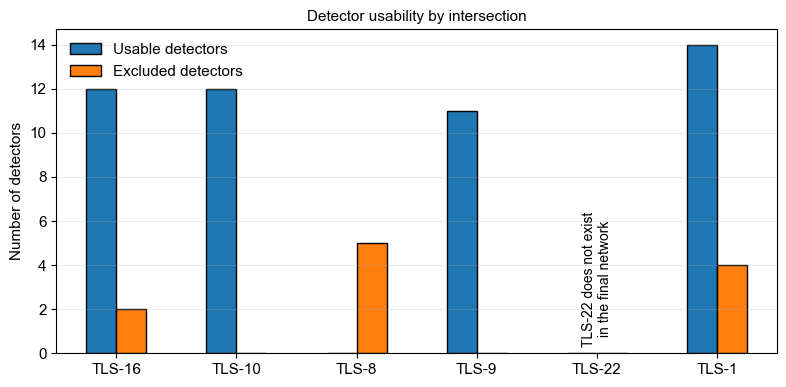

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\figures\detector_usability_by_intersection.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Thesis figure style
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

# ============================================================
# Output directory
# ============================================================

out_dir = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\aktuell_detectors_output\figures"
)
out_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# Detector usability summary
# ============================================================

df = pd.DataFrame({
    "Intersection": ["TLS-16", "TLS-10", "TLS-8", "TLS-9", "TLS-22", "TLS-1"],
    "Usable detectors": [12, 12, 0, 11, 0, 14],
    "Excluded detectors": [2, 0, 5, 0, 0, 4],
})

# ============================================================
# Plot
# ============================================================

ax = df.set_index("Intersection")[[
    "Usable detectors",
    "Excluded detectors"
]].plot(
    kind="bar",
    figsize=(8, 4),
    edgecolor="black"
)

# ============================================================
# Labels and styling
# ============================================================

ax.set_ylabel("Number of detectors")
ax.set_xlabel("")
ax.set_title("Detector usability by intersection")

ax.grid(axis="y", alpha=0.25)

ax.legend(frameon=False)

# TLS-22 annotation
ax.text(
    4, 0.3,
    "TLS-22 does not exist\nin the final network",
    rotation=90,
    ha="center",
    va="bottom",
    fontsize=10
)

plt.xticks(rotation=0)

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================

fig_path = out_dir / "detector_usability_by_intersection.png"

plt.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {fig_path}")